**Hand Written Digits Classification**

**Load data from kagglehub**

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olafkrastovski/handwritten-digits-0-9")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'handwritten-digits-0-9' dataset.
Path to dataset files: /kaggle/input/handwritten-digits-0-9


**List all sub directories**

In [2]:
import os
print(os.listdir(path))

['7', '2', '5', '8', '0', '3', '1', '4', '9', '6']


**Display 5 images in each folder**

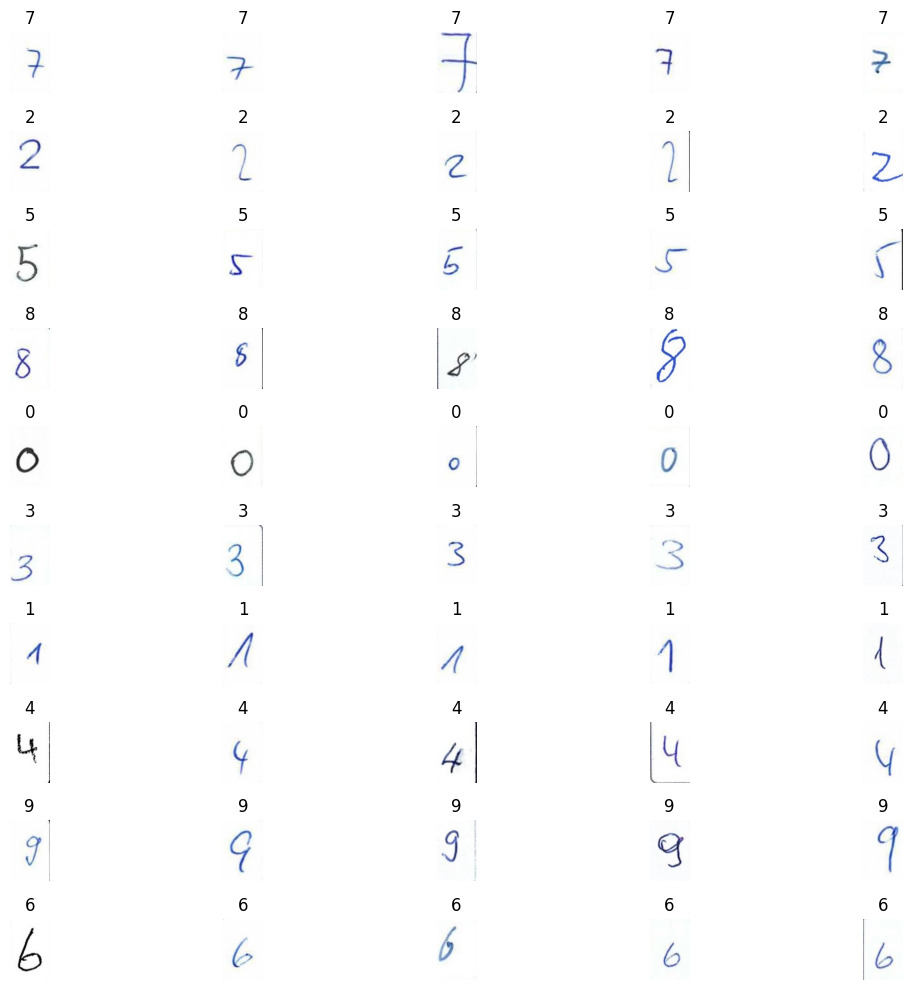

In [3]:
import matplotlib.pyplot as plt
from PIL import Image #Python image library

plt.figure(figsize=(12,10))
i = 1
for class_name in os.listdir(path): # looping through all folders
  class_path = os.path.join(path,class_name) # add main path to each folder
  if os.path.isdir(class_path): # if folder exists
    images =os.listdir(class_path)[:5] #  taking 5 images in each folder

    for img in images:
      img_path = os.path.join(class_path,img)
      img = Image.open(img_path)

      plt.subplot(10,5,i)
      plt.imshow(img)
      plt.title(class_name)
      plt.axis('off')

      i+=1
plt.tight_layout()
plt.show()



**count the number of images in each folder**

In [4]:
for x in os.listdir(path):
  class_path = os.path.join(path,x)
  count = len(os.listdir(class_path))
  print(x ,'-->',count)

7 --> 2116
2 --> 2233
5 --> 2126
8 --> 2085
0 --> 2236
3 --> 2202
1 --> 2241
4 --> 2179
9 --> 2016
6 --> 2121


**Create dataframe with image path and labels**

In [5]:
import pandas as pd
df =[]
for label in os.listdir(path):
  class_path = os.path.join(path,label)
  if os.path.isdir(class_path):
    for img in os.listdir(class_path):
      img_path = os.path.join(class_path,img)
      df.append([img_path,label])
data = pd.DataFrame(df,columns=['img_path','label'])


In [6]:
data

,img_path,label
0,/kaggle/input/handwritten-digits-0-9/7/Seven_f...,7
1,/kaggle/input/handwritten-digits-0-9/7/Seven_f...,7
2,/kaggle/input/handwritten-digits-0-9/7/Seven_f...,7
3,/kaggle/input/handwritten-digits-0-9/7/Seven_f...,7
4,/kaggle/input/handwritten-digits-0-9/7/Seven_f...,7
...,...,...
21550,/kaggle/input/handwritten-digits-0-9/6/Six_ful...,6
21551,/kaggle/input/handwritten-digits-0-9/6/Six_ful...,6
21552,/kaggle/input/handwritten-digits-0-9/6/Six_ful...,6
21553,/kaggle/input/handwritten-digits-0-9/6/Six_ful...,6


**Shuffle data**

In [7]:
data = data.sample(frac=1,random_state=42).reset_index()
data

,index,img_path,label
0,8645,/kaggle/input/handwritten-digits-0-9/0/Zero_fu...,0
1,12353,/kaggle/input/handwritten-digits-0-9/3/Three_f...,3
2,3261,/kaggle/input/handwritten-digits-0-9/2/Two_ful...,2
3,11187,/kaggle/input/handwritten-digits-0-9/3/Three_f...,3
4,19142,/kaggle/input/handwritten-digits-0-9/9/Nine_fu...,9
...,...,...,...
21550,11284,/kaggle/input/handwritten-digits-0-9/3/Three_f...,3
21551,11964,/kaggle/input/handwritten-digits-0-9/3/Three_f...,3
21552,5390,/kaggle/input/handwritten-digits-0-9/5/Five_fu...,5
21553,860,/kaggle/input/handwritten-digits-0-9/7/Seven_f...,7


**find height and width of an image**

In [8]:
img_path = data['img_path'][0]
img = Image.open(img_path)
height,width = img.size
print('height: ',height,'width: ',width)

height:  90 width:  140


**Split data for training,validation and testing**

In [18]:
# images are huge
# Validation : We will be training deep learning model with images in batches
# After learning every batch model is evaluated we call that process as validation
# 70% for training
# 15% for validation
# 15% for testing
train_size =int(0.7*len(data))
val_size = int(0.15 * len(data))
test_size = int(0.15*len(data))
print("train_size-->",train_size)
print("val_size-->",val_size)
print("test_size-->",test_size)

train_data = data.iloc[:train_size] # data.iloc[:15088]
val_data =data.iloc[train_size:train_size+val_size]#data.iloc[15088:15088+3233]
test_data = data.iloc[train_size+val_size:] # data.iloc[15088+3233:]

print('train_data',len(train_data))
print('val_data',len(val_data))
print('test_data',len(test_data))

train_size--> 15088
val_size--> 3233
test_size--> 3233
train_data 15088
val_data 3233
test_data 3234


**Image Preprocessing**

In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [20]:
batch_size=32
img_height=128
img_width = 128

In [21]:
data_generator = ImageDataGenerator(
    rescale=1.0/255, # pixel range from 0-255 converted into 0 to 1
    rotation_range=40 ,# rotates an image upto +_40 degree
    width_shift_range=0.2, #moves an image to right and left by 20%
    height_shift_range=0.2 , #moves image up and down by 20%
    shear_range =0.2 , # slant image in sideways,
    zoom_range=0.2,
    horizontal_flip = True, # flips images to left or right
    fill_mode ='nearest') # gaps in image is filled with nearest pixels.

In [24]:
train_generator = data_generator.flow_from_dataframe(
    dataframe = train_data,
    x_col = 'img_path',
    y_col ='label',
    target_size=(img_height,img_width),
    batch_size =batch_size,
    class_mode ='categorical',
    shuffle=True,seed=42)

Found 15088 validated image filenames belonging to 10 classes.


In [26]:
test_generator = data_generator.flow_from_dataframe(
    dataframe=test_data,
    x_col='img_path',
    y_col = 'label',
    target_size=(img_height,img_width),
    batch_size =batch_size,
    class_mode ='categorical',
    shuffle =True,seed=42
)

Found 3234 validated image filenames belonging to 10 classes.


In [27]:
val_generator = data_generator.flow_from_dataframe(
    dataframe=val_data,
    x_col='img_path',
    y_col = 'label',
    target_size=(img_height,img_width),
    batch_size =batch_size,
    class_mode ='categorical',
    shuffle =True,seed=42
)

Found 3233 validated image filenames belonging to 10 classes.


In [32]:
for image_batch,labels_batch in train_generator:
  print(f"Train shape: {image_batch.shape} (Batches={len(train_generator)})")
  break

for image_batch,labels_batch in test_generator:
  print(f"Test shape: {image_batch.shape} (Batches={len(test_generator)})")
  break

for image_batch,labels_batch in val_generator:
  print(f"val shape: {image_batch.shape} (Batches={len(val_generator)})")
  break

Train shape: (32, 128, 128, 3) (Batches=472)
Test shape: (32, 128, 128, 3) (Batches=102)
val shape: (32, 128, 128, 3) (Batches=102)


**CNN Model**

In [33]:
from tensorflow.keras import layers,models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy

In [34]:
# cnn model
n_classes = 10
cnn_model = models.Sequential([
    layers.Input(shape=(128,128,3)),
    layers.Conv2D(32,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes,activation='softmax')
])

In [35]:
cnn_model.compile(loss=categorical_crossentropy,optimizer=Adam(),metrics=['accuracy'])

In [ ]:
cnn = cnn_model.fit(train_generator,epochs =5,validation_data=val_generator,verbose=1)

Epoch 1/5
472/472 ━━━━━━━━━━━━━━━━━━━━ 482s 1s/step - accuracy: 0.1281 - loss: 2.2863 - val_accuracy: 0.1720 - val_loss: 2.2235
Epoch 2/5
472/472 ━━━━━━━━━━━━━━━━━━━━ 460s 975ms/step - accuracy: 0.3048 - loss: 1.9744 - val_accuracy: 0.4098 - val_loss: 1.6905
Epoch 3/5
472/472 ━━━━━━━━━━━━━━━━━━━━ 456s 965ms/step - accuracy: 0.4785 - loss: 1.5153 - val_accuracy: 0.5196 - val_loss: 1.4131
Epoch 4/5
365/472 ━━━━━━━━━━━━━━━━━━━━ 1:36 904ms/step - accuracy: 0.5644 - loss: 1.2957

**Evaluate the model**

In [ ]:
train_loss, train_accuracy = cnn_model.evaluate(train_generator, verbose=1)
print(f'Training accuracy: {train_accuracy:.4f}')

# Evaluate on the test data
test_loss, test_accuracy = cnn_model.evaluate(test_generator, verbose=1)
print(f'Test accuracy: {test_accuracy:.4f}')

In [9]:
# Retrieve metrics from the training history
acc = cnn.history['accuracy']
val_acc = cnn.history['val_accuracy']
loss = cnn.history['loss']
val_loss = cnn.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# Plot accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for CNN')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for CNN')
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "three.jpg"

# Load image
img = image.load_img(img_path, target_size=(128, 128))  # same as training

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

**Predictions**

In [9]:
prediction = cnn_model.predict(img_array)
prediction